# Task 1

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import uniform

# 1.1 
def generate_samples(n, theta, num_samples):
    return uniform.rvs(scale=theta, size=(num_samples, n))

true_theta = 2.0

num_samples = 10000
sample_sizes = [2**i for i in range(2, 17)]  # 2^2 to 2^16
sample_points = {}

for n in sample_sizes:
    sample_points[n] = generate_samples(n, true_theta, num_samples)

In [5]:
# 1.2 
# Biased estimator function
def biased_estimator(samples):
    return np.max(samples, axis=1)

# Unbiased estimator function
def unbiased_estimator(samples):
    return 2 * np.mean(samples, axis=1)

In [6]:
# 1.3
num_samples = 10000
sample_estimates_biased = {}
sample_estimates_unbiased = {}

m = 15
for i in range(2, m + 2):
    n = 2 ** i
    samples = generate_samples(n, true_theta, num_samples)
    sample_estimates_biased[n] = biased_estimator(samples)
    sample_estimates_unbiased[n] = unbiased_estimator(samples)

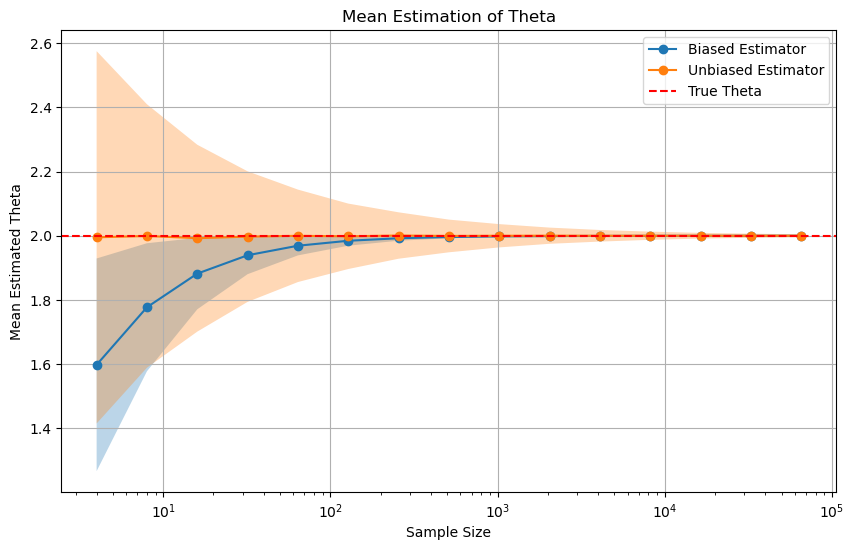

In [10]:
# 1.4
mean_estimates_biased = [np.mean(estimates) for estimates in sample_estimates_biased.values()]
std_estimates_biased = [np.std(estimates) for estimates in sample_estimates_biased.values()]

mean_estimates_unbiased = [np.mean(estimates) for estimates in sample_estimates_unbiased.values()]
std_estimates_unbiased = [np.std(estimates) for estimates in sample_estimates_unbiased.values()]

sample_sizes = list(sample_estimates_biased.keys())

plt.figure(figsize=(10, 6))

plt.plot(sample_sizes, mean_estimates_biased, label='Biased Estimator', marker='o')
plt.plot(sample_sizes, mean_estimates_unbiased, label='Unbiased Estimator', marker='o')

plt.fill_between(sample_sizes, np.array(mean_estimates_biased) - np.array(std_estimates_biased),
                 np.array(mean_estimates_biased) + np.array(std_estimates_biased), alpha=0.3)
plt.fill_between(sample_sizes, np.array(mean_estimates_unbiased) - np.array(std_estimates_unbiased),
                 np.array(mean_estimates_unbiased) + np.array(std_estimates_unbiased), alpha=0.3)

plt.axhline(y=true_theta, color='r', linestyle='--', label='True Theta')

plt.xlabel('Sample Size')
plt.ylabel('Mean Estimated Theta')
plt.xscale('log')
plt.title('Mean Estimation of Theta')
plt.legend()
plt.grid(True)
plt.show()


# Task 2

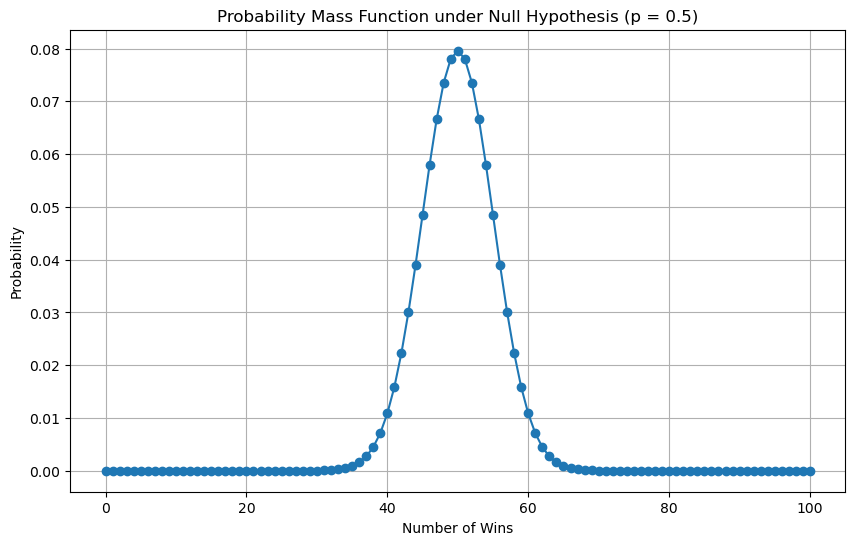

In [13]:
from scipy.stats import binom

# 2.1
# I'll use 0.05 for the confidence value

# 2.2
n_trials = 100
n_wins = 35
p_null = 0.5
alpha = 0.01

x = np.arange(0, n_trials+1)
pmf_null = binom.pmf(x, n_trials, p_null)

plt.figure(figsize=(10, 6))
plt.plot(x, pmf_null, marker='o')
plt.xlabel('Number of Wins')
plt.ylabel('Probability')
plt.title('Probability Mass Function under Null Hypothesis (p = 0.5)')
plt.grid(True)
plt.show()

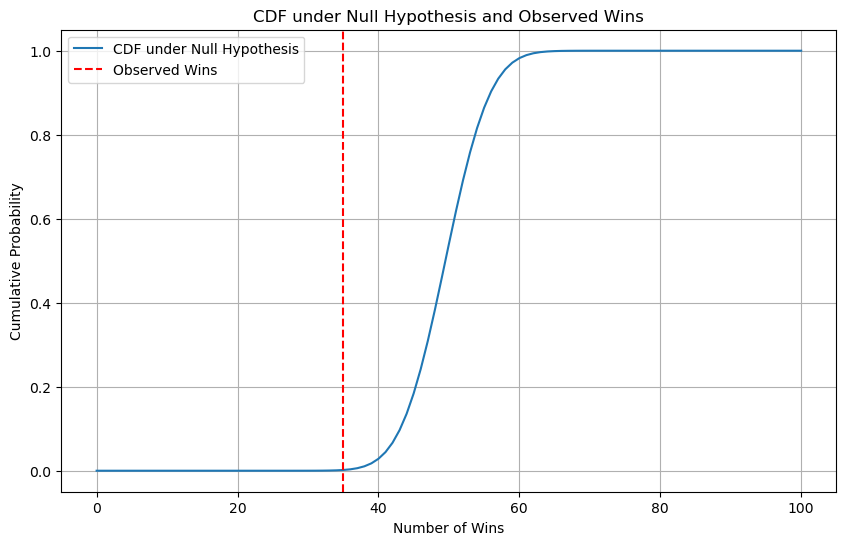

P-value: 0.0017588208614850794


In [16]:
# 2.3
p_value = binom.cdf(n_wins, n_trials, p_null)

plt.figure(figsize=(10, 6))
plt.plot(x, binom.cdf(x, n_trials, p_null), label='CDF under Null Hypothesis')
plt.axvline(x=n_wins, color='r', linestyle='--', label='Observed Wins')
plt.xlabel('Number of Wins')
plt.ylabel('Cumulative Probability')
plt.title('CDF under Null Hypothesis and Observed Wins')
plt.legend()
plt.grid(True)
plt.show()

print("P-value:", p_value)

In [17]:
# 2.4 Conclusion
if p_value < alpha:
    print("Reject the null hypothesis.")
else:
    print("Fail to reject the null hypothesis.")

Reject the null hypothesis.
